1. state transition prob function
2. solve it using
    value iteration
    policy iteration
    matrix methods
(using numpy only)

3. tried out various reward schemes
4. policy evaluation code using monte carlo
5. plotting some graphs for visualization


In [ ]:
import gymnasium as gym

env = gym.make("FrozenLake-v1", render_mode="ansi", map_name="8x8", is_slippery=True)
env.reset()
print(env.render())


SFFFFFFF
FFFFFFFF
FFFHFFFF
FFFFFHFF
FFFHFFFF
FHHFFFHF
FHFFHFHF
FFFHFFFG



In [15]:
print("Action space: ", env.action_space)
print("Observation space: ", env.observation_space)

Action space:  Discrete(4)
Observation space:  Discrete(64)


In [16]:
env.reset()

(0, {'prob': 1})

In [17]:
#generate random action
randomAction= env.action_space.sample()
returnValue = env.step(randomAction)
# format of returnValue is (observation,reward, terminated, truncated, info)
# observation (object)  - observed state
# reward (float)        - reward that is the result of taking the action
# terminated (bool)     - is it a terminal state
# truncated (bool)      - it is not important in our case (when episode ends due to some external reason like time ended or something like that)
# info (dictionary)     - in our case transition probability

env.render()
print(returnValue)

(0, 0, False, False, {'prob': 0.3333333333333333})


In [18]:
# env.P[state][action]

env.unwrapped.P[0][0]

# output is a list having the following entries
# (transition probability, next state, reward, Is terminal state?)

[(0.33333333333333337, 0, 0, False),
 (0.3333333333333333, 0, 0, False),
 (0.33333333333333337, 8, 0, False)]

In [19]:
import numpy as np

num_states = env.observation_space.n  # 16
num_actions = env.action_space.n  # 4

P = np.zeros((num_states, num_actions, num_states))
R = np.zeros((num_states, num_actions))

for state in range(num_states):
    for action in range(num_actions):
        for transition in env.unwrapped.P[state][action]:
            prob, next_state, reward, terminated = transition
            P[state, action, next_state] += prob
            R[state, action] += prob * reward

VALUE ITERATION

using loops

In [ ]:
V = np.zeros(num_states)
gamma = 0.9
theta = 1e-8

while True:
    delta = 0
    for state in range (0, num_states):
        old_V = V[state]
        action_values = np.zeros(num_actions)
        for action in range(num_actions):
            total_value = R[state, action]

            for next_state in range(num_states):
                prob = P[state, action, next_state]
                total_value += gamma * prob * V[next_state]

            action_values[action] = total_value

        V[state] = np.max(action_values)
        delta = max(delta, abs(old_V - V[state]))

    if delta < theta:
        break

# finding optimal policy
policy = np.zeros(num_states, dtype=int)

for state in range(num_states):
    action_values = np.zeros(num_actions)
    for action in range(num_actions):
        total_value = R[state, action]
        for next_state in range(num_states):
            prob = P[state, action, next_state]
            total_value += gamma * prob * V[next_state]

        action_values[action] = total_value

    policy[state] = np.argmax(action_values)


using numpy

In [ ]:
V = np.zeros(num_states)
gamma = 0.9
theta = 1e-8

while True:
    delta = 0

    for state in range (0, num_states):
        old_V = V[state]

        # P[state, :, :] shape- (4x16)
        # V shape: (16x1)
        # R[state, :] shape: (4x1)
        action_values = R[state, :] + gamma * np.dot(P[state, :, :], V)

        V[state] = np.max(action_values)
        delta = max(delta, abs(old_V - V[state]))

    if delta < theta:
        break

# finding optimal policy
# P (16x4x16)
# V (16x1)
expected_future_value = np.dot(P, V) # (16x4x1)

Q_matrix = R + gamma * expected_future_value # (16x4)

policy = np.argmax(Q_matrix, axis=1) # (16x1)

POLICY ITERATION

In [21]:
V = np.zeros(num_states)
pi_policy = np.zeros(num_states, dtype = int)

gamma = 0.9
theta = 1e-8

while True:
    # policy evaluation
    while True:
        delta = 0
        for state in range (0, num_states):
            old_V = V[state]
            action = policy[state]

            # P[state, action, :] (16x1)
            V[state] = R[state, action] + gamma * np.dot(P[state, action, :], V)
            delta = max(delta, abs(old_V - V[state]))

        if delta < theta:
            break

    # policy improvement
    old_policy = policy.copy()
    expected_future_value = np.dot(P, V)
    Q_matrix = R + gamma * expected_future_value
    pi_policy = np.argmax(Q_matrix, axis=1)

    if np.array_equal(old_policy, pi_policy):
        break


In [22]:
import matplotlib.pyplot as plt

def plot_policy_on_frozen_lake(env, policy, title="FrozenLake policy"):
	desc = np.asarray(env.unwrapped.desc, dtype=str)
	policy_grid = np.asarray(policy).reshape(desc.shape)
	arrows = np.array(["<", "v", ">", "^"])
	colors = {
		"S": "#9be7a1",
		"F": "#dceefb",
		"H": "#3a3a3a",
		"G": "#ffd54f",
	}

	fig, ax = plt.subplots(figsize=(8, 8))
	for r in range(desc.shape[0]):
		for c in range(desc.shape[1]):
			tile = desc[r, c]
			rect = plt.Rectangle((c, desc.shape[0] - 1 - r), 1, 1, facecolor=colors[tile], edgecolor="black", linewidth=1.5)
			ax.add_patch(rect)

			if tile == "H":
				label = "H"
			elif tile == "G":
				label = "G"
			elif tile == "S":
				label = f"S{arrows[policy_grid[r, c]]}"
			else:
				label = arrows[policy_grid[r, c]]

			ax.text(c + 0.5, desc.shape[0] - 1 - r + 0.5, label, ha="center", va="center", fontsize=16, fontweight="bold", color="black")

	ax.set_xlim(0, desc.shape[1])
	ax.set_ylim(0, desc.shape[0])
	ax.set_xticks(np.arange(desc.shape[1] + 1))
	ax.set_yticks(np.arange(desc.shape[0] + 1))
	ax.grid(True, color="black", linewidth=1.0)
	ax.set_xticklabels([])
	ax.set_yticklabels([])
	ax.set_aspect("equal")
	ax.set_title(title)
	plt.tight_layout()
	plt.show()



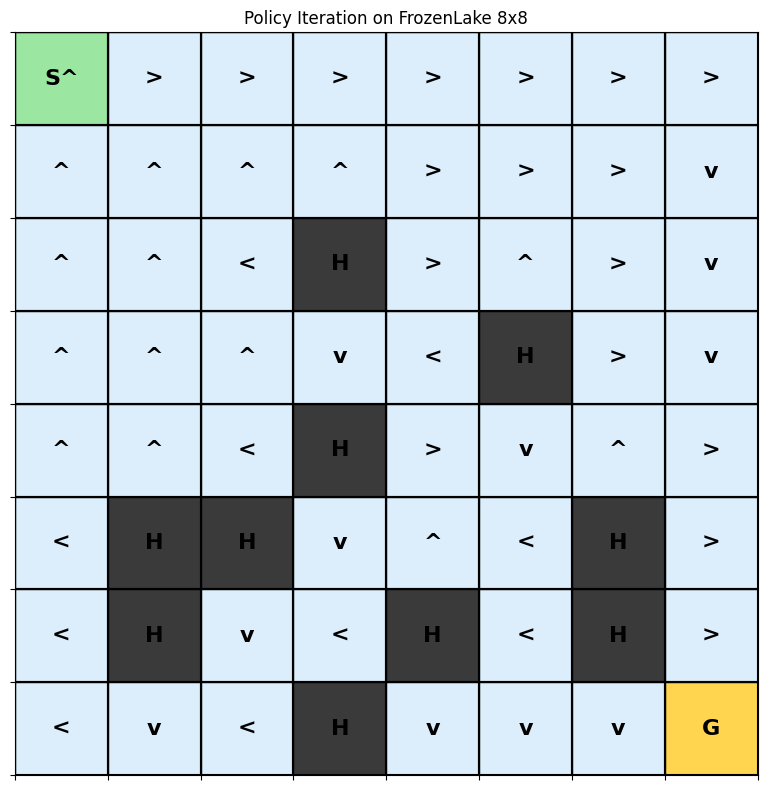

In [23]:
plot_policy_on_frozen_lake(env, pi_policy, title="Policy Iteration on FrozenLake 8x8")